In [74]:
"""Imports"""
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [75]:
"""Constants"""
TANK_RADIUS_1T_mm = 525.78
BOTTOM_PADDLE_1_CENTER = (-175, 325, -1228.05)
BOTTOM_PADDLE_2_CENTER = (-43.18, 185.42, -1228.05)
BOTTOM_PADDLE_MIDPOINT = tuple((a + b) / 2 for a, b in zip(BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER))
TOP_PADDLE_CENTER = (86,86,766.5)

# for reco simulation
TANK_TOP_Z_mm = 666.75
TANK_BOTTOM_Z_mm = -666.75

In [76]:
"""Functions"""
def find_intersection_with_z(reco_entry_xy, reco_exit_xy, z_entry, z_exit, target_z):
    """
    Extends a vector defined by two points (reco entry and exit) and finds its intersection
    with a given z-plane.

    Parameters:
        reco_entry_xy (tuple): (x, y) coordinates of the reconstructed entry point
        reco_exit_xy (tuple): (x, y) coordinates of the reconstructed exit point
        z_entry (float): z-coordinate of reco entry point (usually TANK_TOP_Z_mm)
        z_exit (float): z-coordinate of reco exit point (usually TANK_BOTTOM_Z_mm)
        target_z (float): the z-plane you want to intersect with (e.g. 766.5 or -1228.05)

    Returns:
        (x, y, target_z): the 3D point where the line intersects the target_z plane
    """
    p0 = np.array([reco_entry_xy[0], reco_entry_xy[1], z_entry], dtype=float)
    p1 = np.array([reco_exit_xy[0], reco_exit_xy[1], z_exit], dtype=float)
    direction = p1 - p0

    if direction[2] == 0:
        raise ValueError("Vector is parallel to the z-plane; no intersection.")

    t = (target_z - p0[2]) / direction[2]
    intersection = p0 + t * direction
    return tuple(intersection)

def load_data(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    return data['reco_events'], data['all_bottom_paddle_tags_for_phase']

def calc_radius(x, y):
    """Simple stuff"""
    return (x**2 + y**2)**0.5

# def get_delta_radius(recos, BP_tags, entry_or_exit: str) -> list[float]:
#     delta_radius_list = []
#     num_events = len(recos)
#     for i in range(num_events):
#         # Get which BP was tagged
#         if BP_tags[i] == 1:
#             BP_loc = BOTTOM_PADDLE_1_CENTER
#         elif BP_tags[i] == 2:
#             BP_loc = BOTTOM_PADDLE_2_CENTER
#         elif BP_tags[i] == 3:
# #             BP_loc = BOTTOM_PADDLE_MIDPOINT
#             continue
# #             print("midpoint!")
# #         if not throughgoing(recos[i]):
# #             continue
#         if entry_or_exit == "entry":
#             reco_x = recos[i]["reco"][0]
#             reco_y = recos[i]["reco"][1]
#             true_x = TOP_PADDLE_CENTER[0]
#             true_y = TOP_PADDLE_CENTER[1]
#         elif entry_or_exit == "exit":
#             reco_x = recos[i]["reco"][2]
#             reco_y = recos[i]["reco"][3]
#             true_x = BP_loc[0]
#             true_y = BP_loc[1]
#         reco_r = calc_radius(reco_x, reco_y)
#         true_r = calc_radius(true_x, true_y)
#         if reco_r > 520: continue # tried to fix big peak at 404
# #         if calc_radius(recos[i]["reco"][0], recos[i]["reco"][1]) > 500: continue
#         delta_radius_list.append(np.abs(reco_r - true_r))
#     return delta_radius_list

def get_delta_radius(recos, BP_tags, entry_or_exit: str) -> list[float]:
    delta_radius_list = []
    num_events = len(recos)
    for i in range(num_events):
        # Get which BP was tagged
        if BP_tags[i] == 1:
            BP_loc = BOTTOM_PADDLE_1_CENTER
        elif BP_tags[i] == 2:
            BP_loc = BOTTOM_PADDLE_2_CENTER
        elif BP_tags[i] == 3:
#             BP_loc = BOTTOM_PADDLE_MIDPOINT
            continue
#             print("midpoint!")
#         if not throughgoing(recos[i]):
#             continue
        entry_reco_x = recos[i]["reco"][0]
        entry_reco_y = recos[i]["reco"][1]
        entry_true_x = TOP_PADDLE_CENTER[0]
        entry_true_y = TOP_PADDLE_CENTER[1]

        exit_reco_x = recos[i]["reco"][2]
        exit_reco_y = recos[i]["reco"][3]
        exit_true_x = BP_loc[0]
        exit_true_y = BP_loc[1]
        
        # attempted fix by moving this line. therefore, if it's a bad reco on sim tank size,
        # we skip
#         reco_r = calc_radius(reco_x, reco_y)
#         if reco_r > 520:
#             continue # tried to fix big peak at 404
#         print(calc_radius(entry_reco_x, entry_reco_y))
        if calc_radius(entry_reco_x, entry_reco_y) > 520 or calc_radius(exit_reco_x, exit_true_y) > 520:
            continue

        top_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, TOP_PADDLE_CENTER[2])
        bot_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, BP_loc[2])

        if entry_or_exit == "entry":
            reco_x, reco_y, reco_z = top_intsec
            true_x, true_y = entry_true_x, entry_true_y
        elif entry_or_exit == "exit":
            reco_x, reco_y, reco_z = bot_intsec
            true_x, true_y = exit_true_x, exit_true_y

        reco_r = calc_radius(reco_x, reco_y)
        true_r = calc_radius(true_x, true_y)
#         if reco_r > 520:
#             continue # tried to fix big peak at 404
        delta_radius_list.append(np.abs(reco_r - true_r))
    return delta_radius_list

def get_cos_theta(recos) -> list[float]:
    cos_theta_list = []
    num_events = len(recos)
    for i in range(num_events):
        # Get which BP was tagged
        if BP_tags[i] == 1:
            continue
#             BP_loc = BOTTOM_PADDLE_1_CENTER
        elif BP_tags[i] == 2:
#             continue
            BP_loc = BOTTOM_PADDLE_2_CENTER
        elif BP_tags[i] == 3:
            continue
#             BP_loc = BOTTOM_PADDLE_MIDPOINT
#         if not throughgoing(recos[i]):
#             continue
        reco_x_entry = recos[i]["reco"][0]
        reco_y_entry = recos[i]["reco"][1]
        reco_x_exit = recos[i]["reco"][2]
        reco_y_exit = recos[i]["reco"][3]

        true_x_entry = TOP_PADDLE_CENTER[0]
        true_y_entry = TOP_PADDLE_CENTER[1]
        true_z_entry = TOP_PADDLE_CENTER[2]

        true_x_exit = BP_loc[0]
        true_y_exit = BP_loc[1]
        true_z_exit = BP_loc[2]
        

        true_vec = np.array([true_x_exit, true_y_exit, true_z_exit]) - np.array([true_x_entry, true_y_entry, true_z_entry])
        reco_vec = np.array([reco_x_exit, reco_y_exit, TANK_BOTTOM_Z_mm]) - np.array([reco_x_entry, reco_y_entry, TANK_TOP_Z_mm])

        true_normalized = true_vec / np.linalg.norm(true_vec)
        reco_normalized = reco_vec / np.linalg.norm(reco_vec)
        
        dot_product = np.dot(true_normalized, reco_normalized)
        cos_theta_list.append(dot_product)
#         if dot_product < 0:
#             print(reco_x_entry, reco_y_entry, true_x_entry, true_y_entry, reco_x_exit, reco_y_exit, true_x_exit, true_y_exit)
    return cos_theta_list

def majority_trigger(event) -> bool:
    """Index into the 26th hit. If it is one of the 28 bottom PMTs, we know
    this is a majority trigger event."""
    pmt_num = event["hits"][25][4]
    if pmt_num <= 28:
        return True
    return False

def throughgoing(event) -> bool:
    """Returns a bool if reco points are within top and bottom bases of 
    cylindrical detector, because this implies they did not enter/exit side"""
    reco_x_entry = event["reco"][0]
    reco_y_entry = event["reco"][1]
    reco_x_exit = event["reco"][2]
    reco_y_exit = event["reco"][3]
    if (calc_radius(reco_x_entry, reco_y_entry) < TANK_RADIUS_1T_mm) and (calc_radius(reco_x_exit, reco_y_exit) < TANK_RADIUS_1T_mm):
        return True
    return False

In [77]:
user_file_choice = 2

### eloss files
elosstank_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_all/07_11_25_reco_elosstank_digit_edge_all_disk_d_phase_3_1.pkl"
elosstank_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_all/07_11_25_reco_elosstank_digit_edge_all_disk_d_phase_3_1.pkl"
elosstank_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_per/07_11_25_reco_elosstank_digit_weight_per_disk_d_phase_3_1.pkl"
elosstank_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_per/07_11_25_reco_elosstank_digit_edge_per_disk_d_phase_3_1.pkl"

### numCher files
numCher_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_all/07_11_25_reco_numCher_digit_edge_all_disk_d_phase_3_1.pkl"
numCher_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_per/07_11_25_reco_numCher_digit_edge_per_disk_d_phase_3_1.pkl"
numCher_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_all/07_11_25_reco_numCher_digit_weight_all_disk_d_phase_3_1.pkl"
numCher_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_per/07_11_25_reco_numCher_digit_weight_per_disk_d_phase_3_1.pkl"

file_list = [
    elosstank_digit_weight_all,  #0
    elosstank_digit_edge_all,    #1
    elosstank_digit_weight_per,  #2
    elosstank_digit_edge_per,    #3
    numCher_digit_edge_all,      #4
    numCher_digit_edge_per,      #5
    numCher_digit_weight_all,    #6
    numCher_digit_weight_per     #7
]
### do what you want
real_file0 = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/elosstank_digit_edge_all/07_15_25_disk_l_phase_9_cfd_1_reco_elosstank_digit_edge_all.pkl"
real_file1 = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/elosstank_digit_edge_per/07_15_25_disk_l_phase_9_cfd_1_reco_elosstank_digit_edge_per.pkl"
real_file2 = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/numCher_digit_edge_all/07_15_25_disk_l_phase_9_cfd_1_reco_numCher_digit_edge_all.pkl"
real_file3 = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/numCher_digit_edge_per/07_15_25_disk_l_phase_9_cfd_1_reco_numCher_digit_edge_per.pkl"
file_list = [
    real_file0,
    real_file1,
    real_file2,
    real_file3
]
real_file = real_file1#file_list[user_file_choice]
###
reco_events, BP_tags = load_data(real_file)
reco_type = real_file.split("/")[8]
# reco_type = ""
hist_tag = str(reco_type)
print("total number of recos", len(reco_events))

total number of recos 8507


len values 5819
68th percentile 247.07516942818768 mm


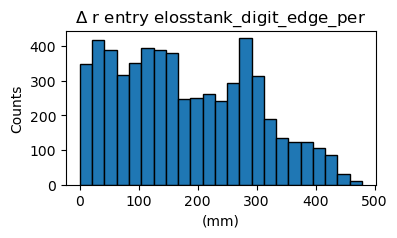

len values 5819
68th percentile 268.9696911551698 mm


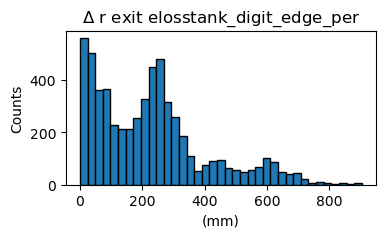

In [78]:
values = get_delta_radius(reco_events, BP_tags, "entry")
print("len values", len(values))
print("68th percentile", np.percentile(values, 68), "mm")
# Create the entry histogram
plt.figure(figsize=(4, 2))
plt.hist(values, bins="auto", edgecolor='black')

# Add labels and title (optional)
plt.xlabel('(mm)')
plt.ylabel('Counts')
plt.title(fr'$\Delta$ r entry {hist_tag}')

# Show the plot
plt.show()



values = get_delta_radius(reco_events, BP_tags, "exit")
print("len values", len(values))
print("68th percentile", np.percentile(values, 68), "mm")
# Create the exit histogram
plt.figure(figsize=(4, 2))
plt.hist(values, bins="auto", edgecolor='black')

# Add labels and title (optional)
plt.xlabel('(mm)')
plt.ylabel('Counts')
plt.title(fr'$\Delta$ r exit {hist_tag}')

# Show the plot
plt.show()

In [79]:
# for i in values:
#     if i > 350:
#         print(i)

68th percentile 7.398695440213455 degrees


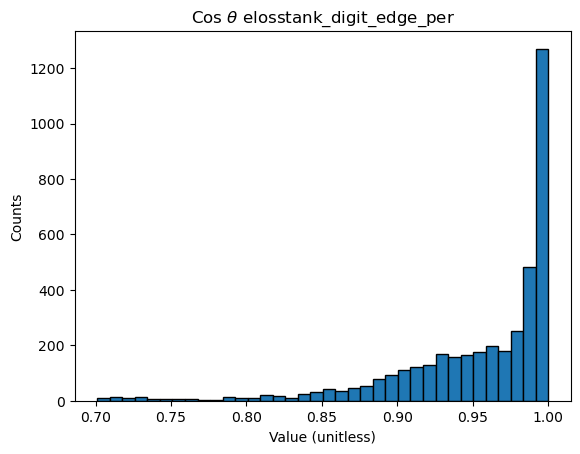

In [80]:
values = get_cos_theta(reco_events)

cos_theta_68 = np.percentile(values, 68)
theta_rad = np.arccos(cos_theta_68)
theta_deg = np.degrees(theta_rad)
print("68th percentile", theta_deg, "degrees")

# Create the histogram
plt.hist(values, bins="auto", edgecolor='black')

# Add labels and title (optional)
plt.xlabel('Value (unitless)')
plt.ylabel('Counts')
plt.title(fr'Cos $\theta$ {hist_tag}')

# Show the plot
plt.show()

In [81]:
results = []
for fileee in file_list:
    reco_events, BP_tags = load_data(fileee)
#     file_tag = fileee.split("/")[10]
    file_tag = fileee.split("/")[8]

    rentry = get_delta_radius(reco_events, BP_tags, "entry")
    rentry68 = np.percentile(rentry, 68)
    
    rexit = get_delta_radius(reco_events, BP_tags, "exit")
    rexit68 = np.percentile(rexit, 68)
    
    cos = get_cos_theta(reco_events)
    cos_theta_68 = np.percentile(cos, 68)
    theta_rad = np.arccos(cos_theta_68)
    theta_deg = np.degrees(theta_rad)
    
    # Append a row of values
    results.append([file_tag, rentry68, rexit68, theta_deg])

# Create a DataFrame
df = pd.DataFrame(results, columns=["file", "rentry68", "rexit68", "theta_deg"])

# Print or export the table
print(df)

                       file    rentry68     rexit68  theta_deg
0  elosstank_digit_edge_all  411.795361  762.063722  34.426280
1  elosstank_digit_edge_per  247.075169  268.969691   7.398695
2    numCher_digit_edge_all  220.835061  350.443598  17.545215
3    numCher_digit_edge_per  190.397189  270.593680  13.068020
